# 01 – Datenaufbereitung

**Bachelorarbeit – Mohamed Mohamady · Universität Paderborn · 2026**
*Rohdaten laden, bereinigen, interpolieren, deskriptive Statistik und Korrelationsmatrix.*

Ausgaben werden in `03_Output/final_run/` gespeichert. Wiederkehrende Bausteine
(Cluster-Definition, Farben, Tabellen-Renderer) liegen in `utils.py`.


## 1. Bibliotheken und Pfade

In [1]:
# Standard data + plotting stack used throughout the notebook
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Shared table renderer (see utils.py next to this notebook)
sys.path.insert(0, r"C:\Users\LEGION\Desktop\Bachelorarbeit\02_Code\final_notebooks")
from utils import save_table

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11

# Single raw input (built in Power BI) and the folder for this run's outputs.
RAW_DATA = Path(r"C:\Users\LEGION\Desktop\Bachelorarbeit\01_Data\final\master_panel.xlsx")
OUTPUT_DIR = Path(r"C:\Users\LEGION\Desktop\Bachelorarbeit\03_Output\final_run")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Datenladen und Bereinigung

In [2]:
# Load the raw panel exactly as exported from Power BI (keep a copy for Table 2).
raw_panel = pd.read_excel(RAW_DATA)

# Build the cleaned version: drop the index helper and Digital Skills
# (Digital Skills is missing for 162 of 216 rows, so it is unusable).
panel = raw_panel.drop(columns=["Digital Skills", "Index"], errors="ignore")
panel = panel.sort_values(["Country", "Year"]).reset_index(drop=True)

# Close the few remaining gaps by linear interpolation within each country.
gap_columns = ["Cloud Computing", "Internet Access", "Internet Use", "Internet Purchases"]
for column in gap_columns:
    panel[column] = panel.groupby("Country")[column].transform(
        lambda series: series.interpolate(method="linear", limit_direction="both"))

# The cleaned panel is a generated artifact; notebooks 02 and 03 read it from here.
clean_path = OUTPUT_DIR / "master_panel_clean.xlsx"
panel.to_excel(clean_path, index=False)

print("Cleaned panel:", panel.shape,
      "| countries:", panel["Country"].nunique(),
      "| years:", sorted(panel["Year"].unique()))
print("Missing values remaining:",
      int(panel.drop(columns=["Country", "Year"]).isnull().sum().sum()))

Cleaned panel: (216, 12) | countries: 27 | years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Missing values remaining: 0


## 3. Tabelle 1 – Variablenübersicht (Tertiary Education = ISCED 3-8)

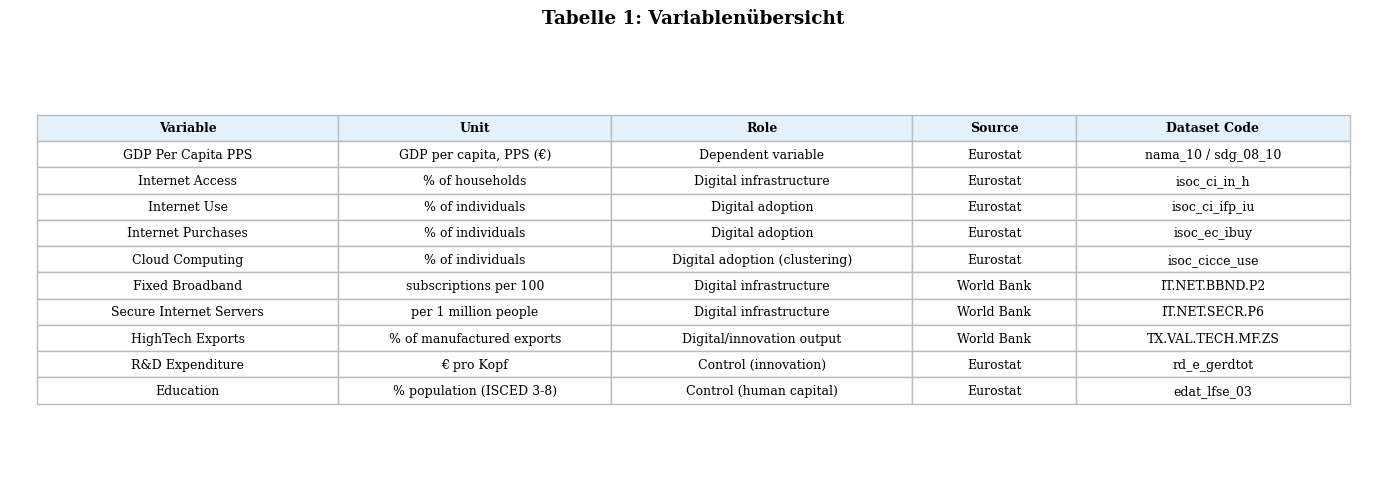

In [3]:
# Documentation table: each variable with its unit, role, source and dataset code.
# Note: R&D expenditure is measured per inhabitant (€ pro Kopf), not in millions.
variables = [
    ["GDP Per Capita PPS", "GDP per capita, PPS (€)", "Dependent variable", "Eurostat", "nama_10 / sdg_08_10"],
    ["Internet Access", "% of households", "Digital infrastructure", "Eurostat", "isoc_ci_in_h"],
    ["Internet Use", "% of individuals", "Digital adoption", "Eurostat", "isoc_ci_ifp_iu"],
    ["Internet Purchases", "% of individuals", "Digital adoption", "Eurostat", "isoc_ec_ibuy"],
    ["Cloud Computing", "% of individuals", "Digital adoption (clustering)", "Eurostat", "isoc_cicce_use"],
    ["Fixed Broadband", "subscriptions per 100", "Digital infrastructure", "World Bank", "IT.NET.BBND.P2"],
    ["Secure Internet Servers", "per 1 million people", "Digital infrastructure", "World Bank", "IT.NET.SECR.P6"],
    ["HighTech Exports", "% of manufactured exports", "Digital/innovation output", "World Bank", "TX.VAL.TECH.MF.ZS"],
    ["R&D Expenditure", "€ pro Kopf", "Control (innovation)", "Eurostat", "rd_e_gerdtot"],
    ["Education", "% population (ISCED 3-8)", "Control (human capital)", "Eurostat", "edat_lfse_03"],
]
save_table(variables, ["Variable", "Unit", "Role", "Source", "Dataset Code"],
           OUTPUT_DIR / "table1_variable_overview.png", "Tabelle 1: Variablenübersicht",
           col_widths=[0.22, 0.20, 0.22, 0.12, 0.20], fontsize=9, figsize=(14, 5))

## 4. Tabelle 2 – Fehlende Werte vor/nach Interpolation

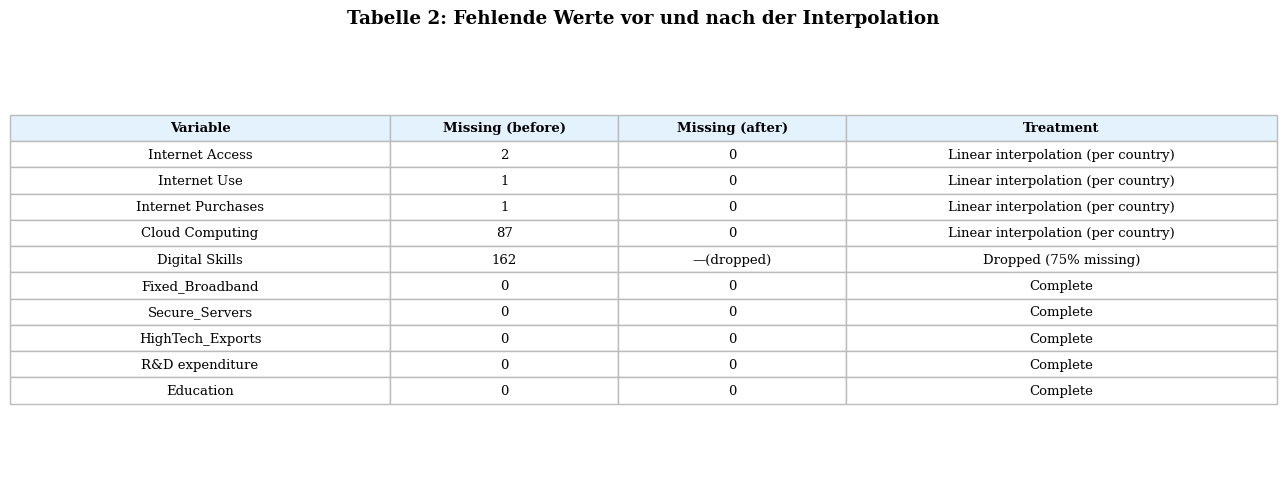

In [4]:
# Compare missing-value counts before (raw) and after cleaning.
tracked_vars = ["Internet Access", "Internet Use", "Internet Purchases", "Cloud Computing", "Digital Skills",
                "Fixed_Broadband", "Secure_Servers", "HighTech_Exports", "R&D expenditure", "Tertiary_Education"]
missing_rows = []
for variable in tracked_vars:
    before = int(raw_panel[variable].isnull().sum()) if variable in raw_panel.columns else 0
    if variable == "Digital Skills":
        after, treatment = "—(dropped)", "Dropped (75% missing)"
    else:
        after = int(panel[variable].isnull().sum())
        treatment = "Linear interpolation (per country)" if before > 0 else "Complete"
    label = "Education" if variable == "Tertiary_Education" else variable
    missing_rows.append([label, str(before), str(after), treatment])

save_table(missing_rows, ["Variable", "Missing (before)", "Missing (after)", "Treatment"],
           OUTPUT_DIR / "table2_missing_values.png",
           "Tabelle 2: Fehlende Werte vor und nach der Interpolation",
           col_widths=[0.30, 0.18, 0.18, 0.34], fontsize=9.5, figsize=(13, 5))

## 5. Deskriptive Statistik – Tabelle 3

                        mean       std       min       25%       50%       75%        max
GDP Per Capita PPS  34718.99  14999.62  15329.30  25444.88  31342.20  38727.05   97689.40
Internet Access        89.88      5.98     67.33     86.36     91.00     94.37      99.18
Internet Use           87.87      7.83     63.41     83.10     89.10     93.72      99.77
Internet Purchases     62.76     16.82     16.06     52.94     64.35     75.89      94.70
Fixed_Broadband        35.08      6.49     19.95     29.54     34.95     40.33      48.93
Secure_Servers      55758.10  64339.12   3695.69  20269.49  33733.64  59302.05  557174.25
HighTech_Exports       15.34      7.94      5.07      9.83     13.30     18.39      53.52
R&D expenditure       660.24    563.26     48.10    202.62    403.86   1202.98    1983.35
Tertiary_Education     77.73      8.56     48.40     74.72     79.50     83.22      89.20


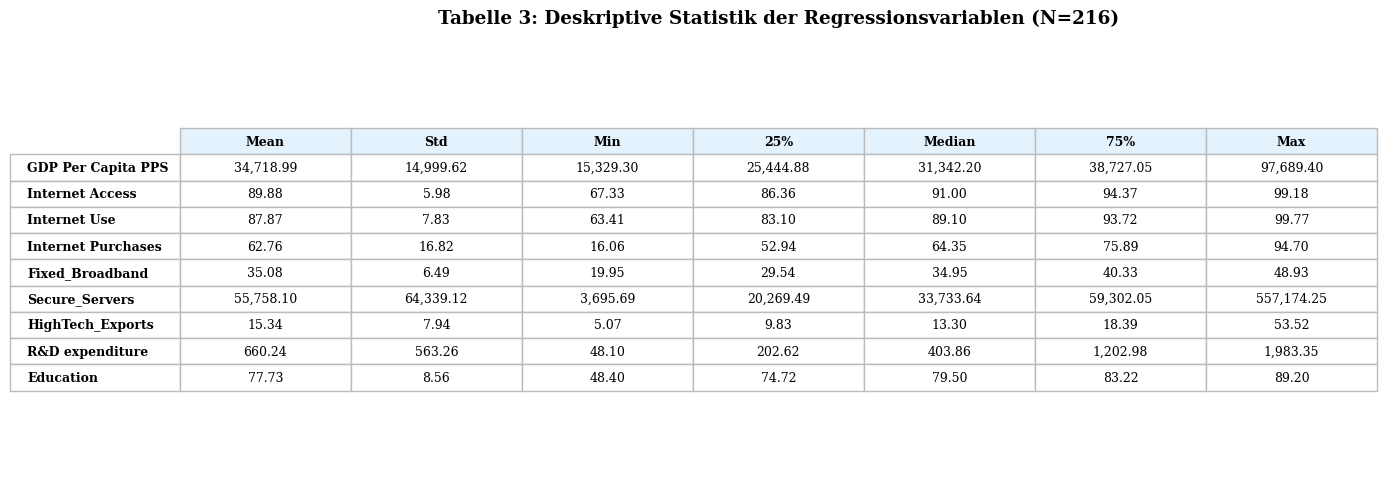

In [5]:
# Summary statistics for the dependent variable and all regressors.
regression_vars = ["GDP Per Capita PPS", "Internet Access", "Internet Use", "Internet Purchases",
                   "Fixed_Broadband", "Secure_Servers", "HighTech_Exports", "R&D expenditure", "Tertiary_Education"]
summary = panel[regression_vars].describe().round(2).T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
print(summary.to_string())
# Visible row label only: rename the education row to "Education" (values unchanged).
summary = summary.rename(index={"Tertiary_Education": "Education"})

summary_rows = [[f"{value:,.2f}" for value in summary.loc[variable]] for variable in summary.index]
save_table(summary_rows, ["Mean", "Std", "Min", "25%", "Median", "75%", "Max"],
           OUTPUT_DIR / "table3_descriptive_stats.png",
           "Tabelle 3: Deskriptive Statistik der Regressionsvariablen (N=216)",
           row_labels=list(summary.index), fontsize=9, figsize=(14, 5))

## 6. Korrelationsmatrix

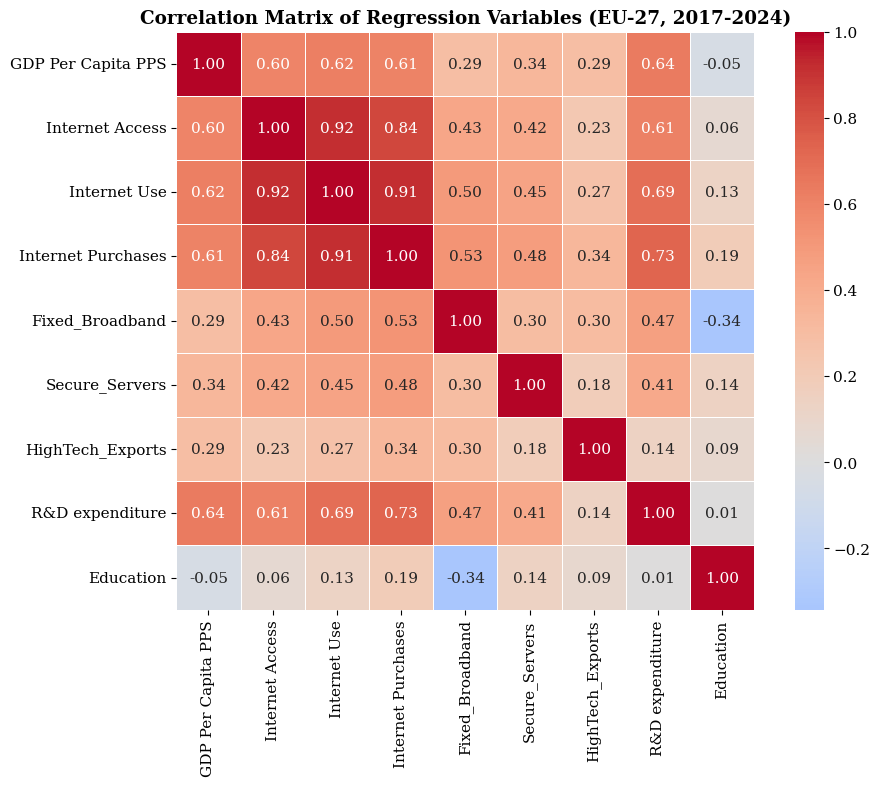

In [6]:
# Correlation heatmap of the regression variables.
correlation = panel[regression_vars].corr()
# Visible label only: show the education control as "Education" (column itself is unchanged).
correlation = correlation.rename(index={"Tertiary_Education": "Education"}, columns={"Tertiary_Education": "Education"})
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Regression Variables (EU-27, 2017-2024)", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()